In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [23]:
# Importando a base de dados
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

In [24]:
df[['BP_Systolic', 'BP_Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df.drop(columns=['Blood Pressure'], inplace=True)


In [25]:
df['BMI Category'] = df['BMI Category'].replace({'Normal Weight':'Normal'})

In [26]:
bin = [20,35,50,80]
label = ['20-35', '36-50', '51+']

df['Age Group'] = pd.cut(df['Age'],
                         bins=bin,
                         labels=label,
                         right=True)

In [27]:
# Criando uma Categoria do Sono com base na duração do sono
# Sono < 6h = Baixo; Sono > 6h e Sono < 8 = Ideal; Sono > 8 = Longo 

limites = [0, 6, 8, 12]
categorias = ['Baixo', 'Ideal', 'Longo']
df["Categoria_Sono"] = pd.cut(
    df["Sleep Duration"],
    bins=limites,
    labels=categorias,
    right=True
)

print(df[["Sleep Duration", "Categoria_Sono"]])


     Sleep Duration Categoria_Sono
0               6.1          Ideal
1               6.2          Ideal
2               6.2          Ideal
3               5.9          Baixo
4               5.9          Baixo
..              ...            ...
369             8.1          Longo
370             8.0          Ideal
371             8.1          Longo
372             8.1          Longo
373             8.1          Longo

[374 rows x 2 columns]


In [28]:
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,BP_Systolic,BP_Diastolic,Age Group,Categoria_Sono
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NaN,126,83,20-35,Ideal
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80,20-35,Ideal
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80,20-35,Ideal
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90,20-35,Baixo
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90,20-35,Baixo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95,51+,Longo
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,68,7000,Sleep Apnea,140,95,51+,Ideal
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95,51+,Longo
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95,51+,Longo


In [29]:
# Vendo as informações dessa base
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Person ID                374 non-null    int64   
 1   Gender                   374 non-null    str     
 2   Age                      374 non-null    int64   
 3   Occupation               374 non-null    str     
 4   Sleep Duration           374 non-null    float64 
 5   Quality of Sleep         374 non-null    int64   
 6   Physical Activity Level  374 non-null    int64   
 7   Stress Level             374 non-null    int64   
 8   BMI Category             374 non-null    str     
 9   Heart Rate               374 non-null    int64   
 10  Daily Steps              374 non-null    int64   
 11  Sleep Disorder           155 non-null    str     
 12  BP_Systolic              374 non-null    int64   
 13  BP_Diastolic             374 non-null    int64   
 14  Age Group            

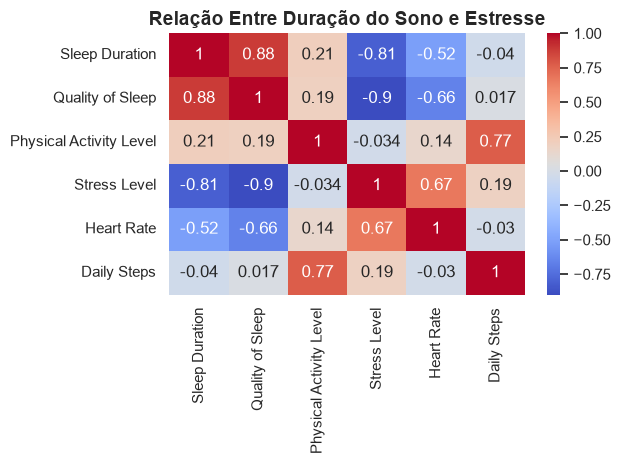

In [30]:
# Criando um Heatmap para analisar as relações entre os dados

cols = ["Sleep Duration", "Quality of Sleep", "Physical Activity Level", "Stress Level", "Heart Rate", "Daily Steps"]

sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Relação Entre Duração do Sono e Estresse", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
# Média de estresse para cada Categoria de sono

print(df.groupby("Categoria_Sono")["Stress Level"].agg("mean"))

Categoria_Sono
Baixo    8.000000
Ideal    5.526882
Longo    3.034483
Name: Stress Level, dtype: float64


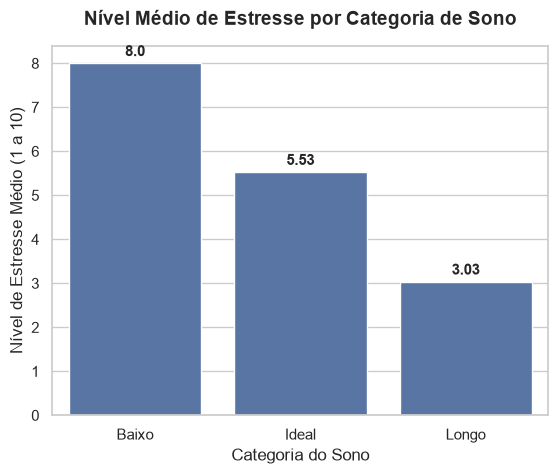

In [32]:
# Plotar gráfico de barra com a relação entre a categoria do sono e o nivel médio de estresse
ax = sns.barplot(data=df, x="Categoria_Sono", y="Stress Level", errorbar=None)

# Personalizar títulos e rótulos
plt.title("Nível Médio de Estresse por Categoria de Sono", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Categoria do Sono")
plt.ylabel("Nível de Estresse Médio (1 a 10)", fontsize=12)

# Adicionar os valores numéricos em cima de cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center',
                xytext=(0,8),
                textcoords='offset points',
                fontsize=11, fontweight='bold'
                )

plt.show()

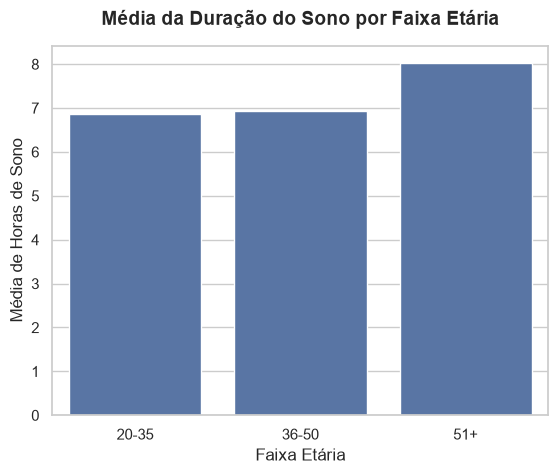

In [33]:
# Gráfico de barras mostrando a Média da Duração do Sono por Faixa Etária
sns.barplot(data=df, x="Age Group", y="Sleep Duration", errorbar=None)

# Personalizar títulos e rótulos
plt.title("Média da Duração do Sono por Faixa Etária", fontweight='bold', fontsize=14, pad=15)
plt.xlabel("Faixa Etária")
plt.ylabel("Média de Horas de Sono")
plt.show()

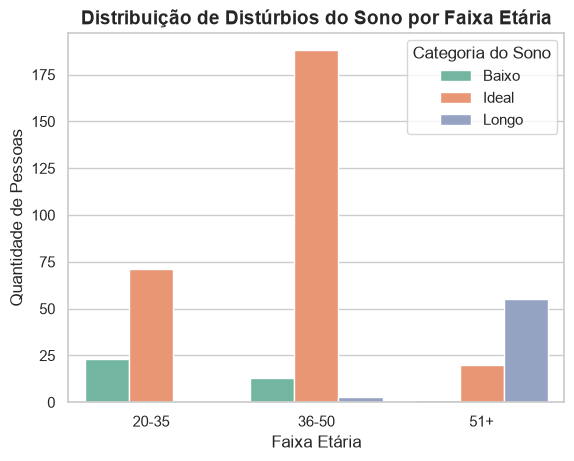

In [34]:
# Distribuição de Distúrbios do Sono por Categoria de Sono

sns.countplot(data=df, x='Age Group', hue='Categoria_Sono', palette='Set2'
)

# Personalizar títulos e rótulos
plt.title('Distribuição de Distúrbios do Sono por Faixa Etária', fontsize=14, fontweight='bold')
plt.xlabel('Faixa Etária')
plt.ylabel('Quantidade de Pessoas')
plt.legend(title='Categoria do Sono')
plt.show()

C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_15260\2233936638.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Age Group', y='Stress Level', palette='Pastel1')


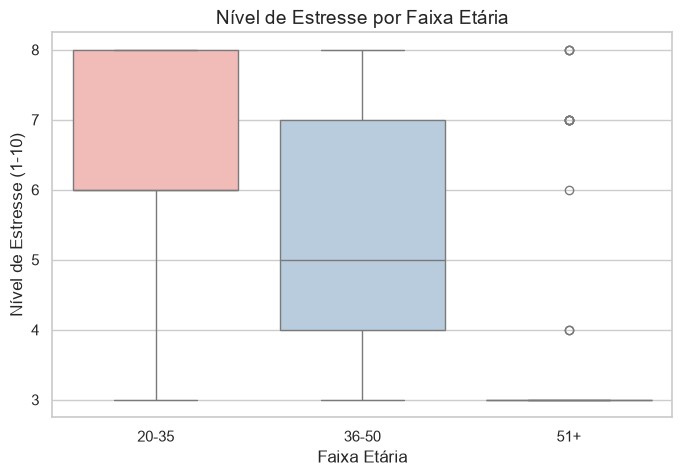

In [35]:
# BoxPlot de Nível de Estresse por Faixa Etária
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Age Group', y='Stress Level', palette='Pastel1')

# Personalizar títulos e rótulos
plt.title('Nível de Estresse por Faixa Etária', fontsize=14)
plt.xlabel('Faixa Etária')
plt.ylabel('Nível de Estresse (1-10)')
plt.show()

C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_15260\1837108657.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,


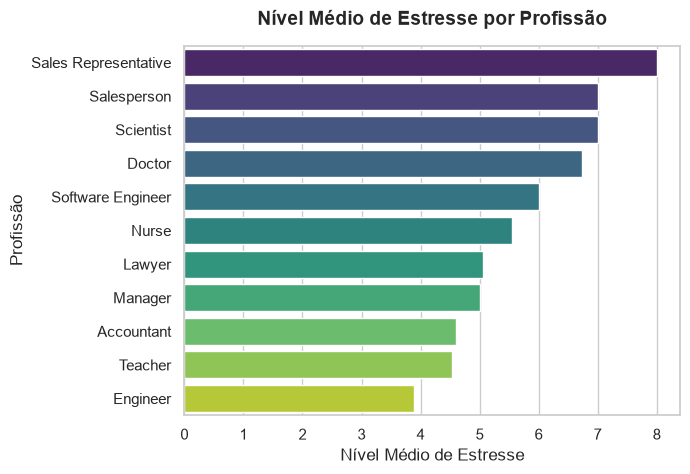

In [36]:
# Descobrir a Média de estresse com base na Profissão

estresse_prof = df.groupby("Occupation")["Stress Level"].agg("mean").sort_values(ascending=False).index

# Plotando gráfico de barra com a relação de estresse por profissão
sns.barplot(data=df, 
            x="Stress Level", 
            y="Occupation", 
            errorbar=None, 
            order=estresse_prof,
            palette="viridis")

# Personalizar títulos e rótulos
plt.title("Nível Médio de Estresse por Profissão", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Nível Médio de Estresse", fontsize=12)
plt.ylabel("Profissão", fontsize=12)

plt.show()

In [37]:
# Criando um DataFrame com as médias de Estresse e Qualidade do Sono por profissão
df_profissoes = df.groupby("Occupation")[["Stress Level", "Quality of Sleep"]].agg("mean").reset_index()
df_profissoes

,Occupation,Stress Level,Quality of Sleep
0,Accountant,4.594595,7.891892
1,Doctor,6.732394,6.647887
2,Engineer,3.888889,8.412698
3,Lawyer,5.063830,7.893617
4,Manager,5.000000,7.000000
5,Nurse,5.547945,7.369863
6,Sales Representative,8.000000,4.000000
7,Salesperson,7.000000,6.000000
8,Scientist,7.000000,5.000000
9,Software Engineer,6.000000,6.500000


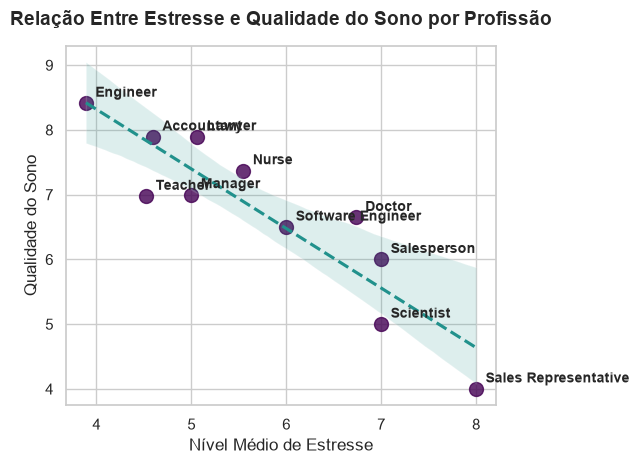

In [38]:

# Criando gráfico de dispersão com uma linha de tendência (regressão)
sns.regplot(
    data=df_profissoes,
    x="Stress Level",
    y="Quality of Sleep",
    scatter_kws={"s":100, "color": "#440154"},
    line_kws={"color": "#21918c", "linestyle":"--"}
)

# Adicionando nomes das profissões aos pontos
for i in range(df_profissoes.shape[0]):
    plt.text(
        x=df_profissoes["Stress Level"].iloc[i] + 0.1,
        y=df_profissoes["Quality of Sleep"].iloc[i] + 0.1,
        s=df_profissoes["Occupation"].iloc[i],
        fontsize=10,
        fontweight='semibold'
    )
    
# Personalizar títulos e rótulos
plt.title("Relação Entre Estresse e Qualidade do Sono por Profissão", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Nível Médio de Estresse", fontsize=12)
plt.ylabel("Qualidade do Sono", fontsize=12)
plt.tight_layout()
plt.show()

<Axes: xlabel='Physical Activity Level', ylabel='Quality of Sleep'>

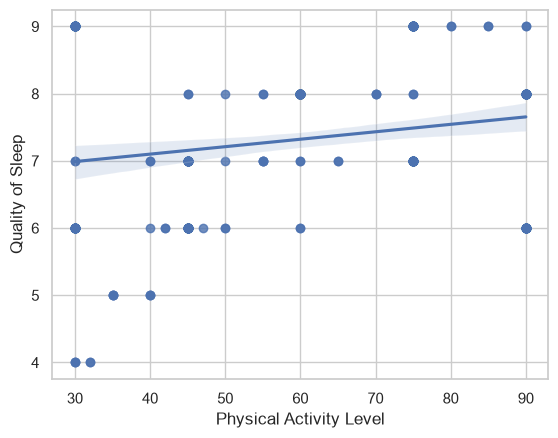

In [39]:
# Criando um gráfico de dispersão para mostrar a relação entre Nivel de Atividade Fisica e Qualidade de Sono

sns.regplot(
    data=df,
    x='Physical Activity Level',
    y='Quality of Sleep',
    )

In [40]:
print(df['Physical Activity Level'].value_counts())

Physical Activity Level
60    70
30    68
45    68
75    67
90    67
40     6
55     6
35     4
50     4
70     3
42     2
32     2
80     2
65     2
85     2
47     1
Name: count, dtype: int64


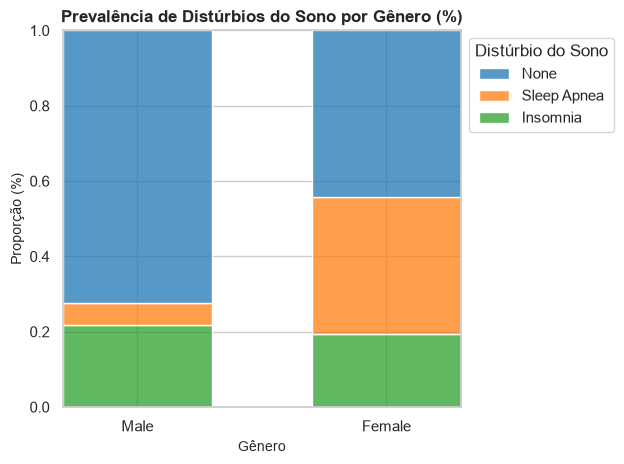

In [41]:
# Gráfico de barra empilhada para mostrar relação de Disturbios do Sono com o Genero

# Tratando valor Nulo
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

# Montando gráfico
ax = sns.histplot(
    data=df,
    x='Gender',
    hue='Sleep Disorder',
    multiple='fill',
    stat='percent',
    shrink=0.6,
    palette='tab10'
)

# Personalização
plt.title('Prevalência de Distúrbios do Sono por Gênero (%)', fontsize=12, fontweight='bold')
plt.xlabel('Gênero', fontsize=10)
plt.ylabel('Proporção (%)', fontsize=10)

# Posicionar a legenda fora do gráfico
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title="Distúrbio do Sono")
plt.tight_layout()
plt.show()
